# Uncertainty Quantification Analysis


In [ ]:
import os
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import cv2

from sklearn.metrics import roc_curve
plt.style.use('utils\painxai.mplstyle')

from scipy.special import xlogy

from scipy.stats import ks_2samp, kstest, mannwhitneyu, kruskal

import matplotlib.patches as patches
import cv2


In [ ]:
folder = ''  # 'VGGFace' or 'ViT'
model = 'ViT_B_32_ENSEMBLE'  # 'VGGFace' or 'ViT'

In [ ]:
path_experiments = f'experiments\\{folder}\\{model}'

filename = 'ensemble_10_results.pkl'

with open(os.path.join(path_experiments, filename), 'rb') as f:
    results = pickle.load(f)

In [ ]:
def IQR(dataframe, mode):
    q75, q50, q25 = np.quantile(dataframe[mode], [0.75, 0.50, 0.25])
    iqr = q75 - q25

    upper_fence = q75 + (1.5 *iqr)
    lower_fence = q25 - (1.5 *iqr)

    print(f"Upper Fence: {upper_fence:.4f}")
    print(f"Q75:         {q75:.4f}")
    print(f"Q50:         {q50:.4f}")
    print(f"Q25:         {q25:.4f}")
    print(f"Lower Fence: {lower_fence:.4f}")

    return upper_fence, q75, q50, q25, lower_fence

In [ ]:
def plot_high_uq_images(high_uq, mode, path=f"imgs_uncertain_{model}.pdf", uq='high'):

    ascending = True if uq == 'low' else False
    high_uq = high_uq.sort_values(by=mode, ascending=ascending)
    high_uq = high_uq.drop_duplicates(subset=['subjects'])
    
    num_rows = 2
    num_cols = 6

    num_images = num_rows * num_cols


    #num_rows = int(np.sqrt(num_images))
    #num_cols = int(np.ceil(num_images / num_rows))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 4))

    for i in range(num_images):
        sample = high_uq.iloc[i]
        img = cv2.resize(cv2.cvtColor(cv2.imread(sample['img_names']), cv2.COLOR_BGR2RGB), (128, 128))

        if sample['labels'] == sample['preds']:
            color = (46, 204, 113)  # Green (RGB)
        else:
            color = (215, 38, 56)   # Red (RGB)


        # Add border by padding image
        border_thickness = 2
        img_with_border = cv2.copyMakeBorder(
            img,
            top=border_thickness,
            bottom=border_thickness,
            left=border_thickness,
            right=border_thickness,
            borderType=cv2.BORDER_CONSTANT,
            value=color
        )

        row = i // num_cols
        col = i % num_cols
        ax = axes[row, col]

        ax.imshow(img_with_border)
        ax.axis('off')

        dataset = sample['img_names'].split('\\')[4].split('_')[1]
        label = "Com Dor" if sample['labels'] == 1 else "Sem Dor"

        ax.set_title(f"{dataset} - {label}", fontsize=20)
        ax.text(
            4.1, 18.6,
            f"p={sample['probs']:.2f}\n$\sigma$={sample[mode]:.2f}",
            fontsize=16,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#9E9E9E', linewidth=2)
        )
        

    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches='tight')


In [ ]:
def plot_high_uq_hist(high_uq, path=f"imgs_uncertain_{model}.pdf"):

    high_uq = high_uq.sort_values(by='subjects')
    
    
    num_images = len(high_uq)
    num_rows = int(np.sqrt(num_images))
    num_cols = int(np.ceil(num_images / num_rows))

    #num_rows = 2
    #num_cols = 5

    # Create subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize = (num_cols * 4, num_rows * 4))

    for i in range(num_images):

        sample = high_uq.iloc[i]

        row = i // num_cols
        col = i % num_cols
        axes[row, col].hist(sample['probs_uq'], edgecolor='black')
        axes[row, col].axis('on')
        axes[row, col].set_xlim(0, 1)
        axes[row, col].set_ylim(0, 15)

    plt.savefig(path, dpi=300, bbox_inches='tight', transparent=True)

## Verifying predictions uncertainty

In [ ]:
def binary_entropy(p, eps=1e-8):
    p = np.clip(p, eps, 1 - eps)  # avoid log(0)
    return -p * np.log(p) - (1 - p) * np.log(1 - p)

In [ ]:
dataframe = pd.DataFrame(results)

dataframe['stds'] = np.array(dataframe['probs_uq'].tolist()).std(axis=1)
#dataframe['stds'] = (dataframe['stds'] - dataframe['stds'].min()) / (dataframe['stds'].max() - dataframe['stds'].min())
dataframe['predictive_entropy'] = binary_entropy(np.mean(dataframe['probs_uq'].tolist(), axis=1))
dataframe['dataset'] = dataframe['img_names'].apply(lambda x: x.split('\\')[4].split('_')[1])
dataframe['corrects'] = dataframe['labels'] == dataframe['preds']
dataframe['subjects'] = dataframe['img_names'].apply(lambda x: x.split('\\')[4].split('_')[2])

In [ ]:
dataframe

In [ ]:
dataframe.to_csv(f"results_uncertainty_{model}.csv", index=False)

In [ ]:
mode = 'stds'

### Uncertainty density distribution for predictions

In [ ]:
fig = plt.figure()
gs = fig.add_gridspec(2, 1,  height_ratios=(3, 1), left=0.1, right=0.9, bottom=0.1, top=0.9, hspace=0.02)

ax_kde = fig.add_subplot(gs[0])
ax_boxplot = fig.add_subplot(gs[1], sharex=ax_kde)

sns.kdeplot(data=dataframe, x=mode, fill=True, ax=ax_kde)
sns.boxplot(data=dataframe, x=mode, width=0.5, ax=ax_boxplot, linewidth=0.9)

ax_kde.set_title('Uncertainty [$\sigma$] distribution over predictions')
ax_kde.set_ylabel('Density')

ax_boxplot.set_xlabel('Uncertainty [$\sigma$]')

In [ ]:
upper_fence, q75, q50, q25, lower_fence = IQR(dataframe, mode=mode)

### High uncertain images

In [ ]:
high_uq = dataframe.sort_values([mode],ascending=False)
   
high_uq_pain = high_uq[high_uq['labels']==1]
high_uq_nopain = high_uq[high_uq['labels']==0]

In [ ]:
plot_high_uq_images(high_uq_pain, mode=mode, path=f"pain_imgs_uncertain_{model}.pdf", uq='high')

In [ ]:
plot_high_uq_images(high_uq_nopain, mode=mode, path=f"nopain_imgs_uncertain_{model}.pdf", uq='high')

### Low uncertainty images

In [ ]:
low_uq = dataframe[(dataframe[mode]<q25)].sort_values([mode],ascending=False) # Outliers

low_uq_pain = low_uq[low_uq['labels']==1]
low_uq_nopain = low_uq[low_uq['labels']==0]

In [ ]:
plot_high_uq_images(low_uq_pain, mode=mode, path=f"pain_imgs_certain_{model}.pdf", uq='low')

In [ ]:
plot_high_uq_images(low_uq_nopain, mode=mode, path=f"nopain_imgs_certain_{model}.pdf", uq='low')

## Mean Face by Uncertainty

In [ ]:
from skimage.transform import AffineTransform, warp

path_mesh = 'Datasets\DatasetFaces\Landmarks'

faces = []
for i in os.listdir(path_mesh):
    with open(os.path.join(path_mesh,f'{i}'), 'rb') as f:
        face_mesh = np.array(pickle.load(f))

    faces.append(face_mesh)

faces_np = np.array(faces)
face_mesh_mean = faces_np.mean(axis=0)

landmarks_mean = np.array([face_mesh_mean[86], 
                           face_mesh_mean[52],
                           face_mesh_mean[61],
                           face_mesh_mean[88],
                           face_mesh_mean[38]])

In [ ]:
bins = [-np.inf, lower_fence, q25, q50, q75, upper_fence, np.inf]

labels = [
        "Below lower fence",
        "Lower fence to Q25",
        "Q25 to Q50",
        "Q50 to Q75",
        "Q75 to upper fence",
        "Above upper fence"
    ]

binned = pd.cut(dataframe[mode], bins=bins, labels=labels, include_lowest=True)

dataframe['bin'] = binned


In [ ]:
path_xai = os.path.join(path_experiments, 'xai_mask')

In [ ]:
from XAI import attribution_mask_processing

In [ ]:
total = []
#total_GC = []
#total_IG = []

for preds in [1, 0]:
    stacked_imgs = []
    #stacked_GCs = []
    #stacked_IGs = []
    # Iterate over each bin (group) and access its values.

    for bin_range, group in dataframe.groupby('bin'):
        #if bin_range == "Below lower fence" or bin_range == "Above upper fence":
            #continue

        print("Bin:", bin_range)
        print(len(group))

        if len(group) == 0:
            stacked_imgs.append(np.zeros((512,512,3)))
            #stacked_GCs.append(np.zeros((512,512)))
            #stacked_IGs.append(np.zeros((512,512)))
            continue

        warped_imgs = []
        #warped_GCs = []
        #warped_IGs = []
        
        for _, row in group.iterrows():
            path_img = row['img_names']
            
            if row['preds'] == preds:

                # Do something with each value in the bin
                img = cv2.imread(path_img)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                with open(os.path.join(path_mesh, path_img.split("\\")[-1].split(".")[0]+".pkl"), 'rb') as f:
                    face_mesh = np.array(pickle.load(f))

                #with open(os.path.join(path_xai, path_img.split("\\")[-1].split(".")[0]+"_GC.pkl"), 'rb') as f:
                 #   GC_mask = np.array(pickle.load(f))

                #if GC_mask.mean() == 0:
                #    GC_mask = np.zeros((512,512))

                #with open(os.path.join(path_xai, path_img.split("\\")[-1].split(".")[0]+"_IG.pkl"), 'rb') as f:
                #    IG_mask = np.array(pickle.load(f))

                #if IG_mask.mean() == 0:
                #    IG_mask = np.zeros((512,512))

                #GC_mask = cv2.resize(GC_mask, (512,512))
                #IG_mask = cv2.resize(IG_mask, (512,512))

                landmarks =  np.array([face_mesh[86], 
                                        face_mesh[52],
                                        face_mesh[61],
                                        face_mesh[88],
                                        face_mesh[38]])
                
                # first align image
                transform_rigid = AffineTransform()
                transform_rigid.estimate(src=landmarks_mean, dst=landmarks)
                result = warp(img, transform_rigid) * 255
                #result_GC = warp(GC_mask, transform_rigid) * 255
                #result_IG = warp(IG_mask, transform_rigid) * 255

                warped_imgs.append(result.astype(np.uint8))
                #warped_GCs.append(result_GC.astype(np.uint8))
                #warped_IGs.append(result_IG.astype(np.uint8))

        if len(warped_imgs) == 0:
            warped_imgs.append(np.zeros((512,512,3),))
            #warped_GCs.append(np.zeros((512,512)))
            #warped_IGs.append(np.zeros((512,512)))
            
        mean_img = np.mean(np.array(warped_imgs), axis=0)/255
        #mean_xai_GC = np.mean(np.array(warped_GCs), axis=0)
        #mean_xai_IG = np.mean(np.array(warped_IGs), axis=0)

        #result_cam_GC, alpha_channel_cam_GC = attribution_mask_processing(mean_xai_GC)
        #result_cam_IG, alpha_channel_cam_IG = attribution_mask_processing(mean_xai_IG)

        stacked_imgs.append(mean_img)
        #stacked_GCs.append(result_cam_GC * alpha_channel_cam_GC)
        #stacked_IGs.append(result_cam_IG * alpha_channel_cam_IG)

    test_img = np.hstack(stacked_imgs) * 255
    #test_GC = np.hstack(stacked_GCs) * 255
    #test_IG = np.hstack(stacked_IGs) * 255

    total.append(test_img.astype(np.uint8))
    #total_GC.append(test_GC.astype(np.uint8))
    #total_IG.append(test_IG.astype(np.uint8))

test_img = np.vstack(total)

# --- 4. Compute difference and absolute difference ---
gray0 = cv2.cvtColor(total[0], cv2.COLOR_RGB2GRAY)
gray1 = cv2.cvtColor(total[1], cv2.COLOR_RGB2GRAY)

diff      = gray0 - gray1
abs_diff  = np.abs(diff)

# --- 5. Normalize for display (0–255) and convert to uint8 ---
norm_diff = cv2.normalize(abs_diff, None, 0, 255, cv2.NORM_MINMAX)
norm_diff = norm_diff.astype(np.uint8)

# --- 6. Apply a colormap for visual emphasis ---
# You can experiment with COLORMAP_JET, COLORMAP_HOT, etc.
diff_cm = cv2.applyColorMap(norm_diff, cv2.COLORMAP_JET)
plt.figure(figsize=(20, 10))
plt.imshow(diff_cm)
#test_GC = np.vstack(total_GC)
#test_IG = np.vstack(total_IG)


In [ ]:
plt.figure(figsize=(20, 10))
plt.imshow(test_img)
plt.axis('off')

plt.savefig(f'average_face_uncertain_{model}.png',dpi=100, bbox_inches='tight' , pad_inches=0)

In [ ]:
plt.figure(figsize=(20, 10))
plt.imshow(test_GC)
plt.axis('off')
if model == "VGGFace":
    facecolor = '#0C5DA5'
elif model == "NCNN":
    facecolor = '#FF9500'
else:
    facecolor = '#00B945'

## Facial Action Units

from facial_features.extractor import *

ear = []
mar = []

for _, row in dataframe.iterrows():
    path_img = row['img_names']

    with open(os.path.join(path_mesh, path_img.split("\\")[-1].split(".")[0]+".pkl"), 'rb') as f:
        face_mesh = np.array(pickle.load(f))

    left_eye_ear = face_mesh[[35,41,42,39,37,36]]
    ear_left = compute_ear(left_eye_ear)

    right_eye_ear = face_mesh[[89,95,96,93,91,90]]
    ear_right = compute_ear(right_eye_ear)

    ear.append(np.mean([ear_left, ear_right]))

    mouth_mar = face_mesh[[65,66,62,70,69,57,60,54]]
    mar.append(compute_mar(mouth_mar))

dataframe['ear'] = ear
dataframe['mar'] = mar


dataframe['ear'] = ['Eyes Closed' if x < 0.16 else 'Eyes Opened'  for x in ear]
dataframe['mar'] = ['Mouth Closed' if x < 0.2 else 'Mouth Opened'  for x in mar]


In [ ]:
dataframe.head()

## Verifying the uncertainty in correct and incorrect predictions

In [ ]:
dataframe.groupby('corrects')['stds'].max()

In [ ]:
ks_2samp(dataframe[dataframe['corrects'] == True][mode], dataframe[dataframe['corrects'] == False][mode])

In [ ]:

# --- K-S test text ---
ks_statistic, p_value = ks_2samp(
    dataframe.loc[dataframe["corrects"] == True,  mode],
    dataframe.loc[dataframe["corrects"] == False, mode],
)

p_text = "p < 0.0001" if p_value < 0.0001 else f"p = {p_value:.4f}"
ks_text = f"Teste K-S\nD = {ks_statistic:.3f} / {p_text}"

# Optional: treat as categories + control order
order = [True, False]  # so "Corretas" appears first

fig, ax = plt.subplots(figsize=(6, 6))

palette = {
    "True":  "#1f77b4",  # blue
    "False": "#ff7f0e",  # orange
}

sns.violinplot(
    data=dataframe,
    x="corrects",
    y=mode,
    palette=palette,
    order=order,
    ax=ax,
    inner="box",   # shows median + IQR lines
    cut=0,              # don't extend beyond data
    linewidth=0.9
)

# Axis labels + tick labels
ax.set_xlabel("Predições")
ax.set_ylabel(r"Incerteza Epistêmica [$\sigma$]")
ax.set_xticklabels(["Corretas", "Incorretas"])

# K-S annotation with white backgroun
ax.text(
    0.02, 0.98, ks_text,
    transform=ax.transAxes,
    fontsize=10,
    va="top", ha="left",
    bbox=dict(
    facecolor=plt.rcParams["figure.facecolor"],
    edgecolor=plt.rcParams["axes.edgecolor"],
    linewidth=plt.rcParams["axes.linewidth"],
    alpha=0.70
)
)

fig.savefig(
    f"uncertainty_corrects_{model}.pdf",
    dpi=300,
    bbox_inches="tight"
)



In [ ]:
ks_statistic, p_value = ks_2samp(dataframe[dataframe['corrects'] == True][mode], dataframe[dataframe['corrects'] == False][mode])

if p_value < 0.0001:
    p_text = f"p < 0.0001"
else:
    p_text = f"p = {p_value:.4f}"
    
ks_text = f"Teste K-S\nD = {ks_statistic:.3f} / {p_text}"


fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(2, 1,  height_ratios=(3, 1), left=0.1, right=0.9, bottom=0.1, top=0.9, hspace=0.02)

ax_kde = fig.add_subplot(gs[0])
ax_boxplot = fig.add_subplot(gs[1], sharex=ax_kde)

sns.kdeplot(data=dataframe, x=mode, hue='corrects', fill=True, ax=ax_kde)
sns.boxplot(data=dataframe, x=mode, y=[""] * len(dataframe), hue='corrects', width=0.5, ax=ax_boxplot, linewidth=0.9)

#ax_kde.set_title('Distribuição da incerteza [$\sigma$] distribution over predictions')
ax_kde.set_ylabel('Densidade')
ax_kde.legend(title="Predições", labels=["Corretas","Incorretas"])
ax_kde.tick_params(axis='x', labelbottom=False)

ax_boxplot.set_xlabel(f'Incerteza Epistêmica [$\sigma$]')
ax_boxplot.get_legend().remove()

ax_kde.text(0.82, 0.7, ks_text, transform=ax_kde.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='center')

plt.savefig(f'uncertainty_corrects_{model}.pdf', 
                    dpi=300, 
                    bbox_inches='tight')

## Verifying uncertainty in Pain and No-pain classes

In [ ]:
dataframe.groupby('preds')['stds'].max()

In [ ]:
ks_2samp(dataframe[dataframe['preds']==0][mode], dataframe[dataframe['preds']==1][mode])

In [ ]:
# --- K-S test ---
ks_statistic, p_value = ks_2samp(
    dataframe.loc[dataframe["preds"] == 0, mode],
    dataframe.loc[dataframe["preds"] == 1, mode],
)

p_text = "p < 0.0001" if p_value < 0.0001 else f"p = {p_value:.4f}"
ks_text = f"Teste K-S\nD = {ks_statistic:.3f} / {p_text}"

# --- Colors: force blue / orange ---
palette = {
    "0": "#1f77b4",  # blue  → Com dor
    "1": "#ff7f0e",  # orange → Sem dor
}

fig, ax = plt.subplots(figsize=(6, 6))

sns.violinplot(
    data=dataframe,
    x="preds",
    y=mode,
    order=[0, 1],
    palette=palette,
    ax=ax,
    inner="box",
    cut=0,
    linewidth=0.9
)

# Labels
ax.set_xlabel("Classe")
ax.set_ylabel(r"Incerteza Epistêmica [$\sigma$]")
ax.set_xticklabels(["Com dor", "Sem dor"])

# K-S annotation (white background)
ax.text(
    0.02, 0.98, ks_text,
    transform=ax.transAxes,
    fontsize=10,
    va="top", ha="left",
    bbox=dict(
    facecolor=plt.rcParams["figure.facecolor"],
    edgecolor=plt.rcParams["axes.edgecolor"],
    linewidth=plt.rcParams["axes.linewidth"],
    alpha=0.70
)
)

fig.savefig(
    f"uncertainty_class_{model}.pdf",
    dpi=300,
    bbox_inches="tight"
)



In [ ]:
ks_statistic, p_value = ks_2samp(dataframe[dataframe['preds']==0][mode], dataframe[dataframe['preds']==1][mode])

if p_value < 0.0001:
    p_text = f"p < 0.0001"
else:
    p_text = f"p = {p_value:.4f}"
    
ks_text = f"Teste K-S\nD = {ks_statistic:.3f} / {p_text}"


fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(2, 1,  height_ratios=(3, 1), left=0.1, right=0.9, bottom=0.1, top=0.9, hspace=0.02)

ax_kde = fig.add_subplot(gs[0])
ax_boxplot = fig.add_subplot(gs[1], sharex=ax_kde)

sns.kdeplot(data=dataframe, x=mode, hue='preds', fill=True, ax=ax_kde)
sns.boxplot(data=dataframe, x=mode, y=[""] * len(dataframe), hue='preds', width=0.5, ax=ax_boxplot, linewidth=0.9)

#ax_kde.set_title('Distribuição da incerteza [$\sigma$] distribution over predictions')
ax_kde.set_ylabel('Densidade')
ax_kde.legend(title="Classe", labels=["Com dor", "Sem dor"])
ax_kde.tick_params(axis='x', labelbottom=False)

ax_kde.text(0.82, 0.7, ks_text, transform=ax_kde.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='center')

ax_boxplot.set_xlabel('Incerteza Epistêmica [$\sigma$]')
ax_boxplot.get_legend().remove()
plt.savefig(f'uncertainty_class_{model}.pdf', 
                    dpi=300, 
                    bbox_inches='tight')

## Dataset Uncertainty

In [ ]:
dataframe.groupby('dataset')['stds'].max()

In [ ]:
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

# --- K-S test ---
ks_statistic, p_value = ks_2samp(
    dataframe.loc[dataframe["dataset"] == "UNIFESP", mode],
    dataframe.loc[dataframe["dataset"] == "iCOPE",  mode],
)

p_text = "p < 0.0001" if p_value < 0.0001 else f"p = {p_value:.4f}"
ks_text = f"Teste K-S\nD = {ks_statistic:.3f} / {p_text}"

# --- Force colors ---
palette = {
    "UNIFESP": "#1f77b4",  # blue
    "iCOPE":   "#ff7f0e",  # orange
}

order = ["UNIFESP", "iCOPE"]

fig, ax = plt.subplots(figsize=(6, 6))

sns.violinplot(
    data=dataframe,
    x="dataset",
    y=mode,
    order=order,
    palette=palette,
    ax=ax,
    inner="box",
    cut=0,
    linewidth=0.9
)

ax.set_xlabel("Dataset")
ax.set_ylabel(r"Incerteza Epistêmica [$\sigma$]")

# K-S annotation (white background)
ax.text(
    0.02, 0.98, ks_text,
    transform=ax.transAxes,
    fontsize=10,
    va="top", ha="left",
    bbox=dict(
    facecolor=plt.rcParams["figure.facecolor"],
    edgecolor=plt.rcParams["axes.edgecolor"],
    linewidth=plt.rcParams["axes.linewidth"],
    alpha=0.70
)
)

fig.savefig(
    f"uncertainty_dataset_{model}.pdf",
    dpi=300,
    bbox_inches="tight"
)


In [ ]:


ks_statistic, p_value = ks_2samp(dataframe[dataframe['dataset']=='UNIFESP'][mode], dataframe[dataframe['dataset']=='iCOPE'][mode])

if p_value < 0.0001:
    p_text = f"p < 0.0001"
else:
    p_text = f"p = {p_value:.4f}"
    
ks_text = f"Teste K-S\nD = {ks_statistic:.3f} / {p_text}"

fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(2, 1,  height_ratios=(3, 1), left=0.1, right=0.9, bottom=0.1, top=0.9, hspace=0.02)

ax_kde = fig.add_subplot(gs[0])
ax_boxplot = fig.add_subplot(gs[1], sharex=ax_kde)

sns.kdeplot(data=dataframe, x=mode, hue='dataset', fill=True, ax=ax_kde)
sns.boxplot(data=dataframe, x=mode, y=[""] * len(dataframe), hue='dataset', width=0.5, ax=ax_boxplot, linewidth=0.9)

#ax_kde.set_title('Distribuição da incerteza [$\sigma$] distribution over predictions')
ax_kde.set_ylabel('Densidade')
ax_kde.legend(title="Dataset", labels=["UNIFESP",'iCOPE'])
ax_kde.tick_params(axis='x', labelbottom=False)

ax_kde.text(0.82, 0.7, ks_text, transform=ax_kde.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='center')

ax_boxplot.set_xlabel('Incerteza Epistêmica [$\sigma$]')
ax_boxplot.get_legend().remove()
ax_boxplot.set(yticks=[])

plt.savefig(f'uncertainty_dataset_{model}.pdf', 
                    dpi=300, 
                    bbox_inches='tight')

## Uncertainty by Probs

In [ ]:
corrects = dataframe[dataframe['corrects']==True]
incorrects = dataframe[dataframe['corrects']==False]

In [ ]:
mode = 'stds'

In [ ]:
plt.figure(figsize=(12,6))

ax1 = plt.subplot(121)
sns.kdeplot(x=corrects['probs'], y=corrects[mode], fill=True, color='#2E86AB')
#plt.scatter(corrects['probs'], corrects[mode], alpha=0.01, color='k')
plt.title('Predições Corretas')
plt.xlabel('Probabilidade Prevista $[p]$')
plt.ylabel('Incerteza $[\sigma]$')


ax2 = plt.subplot(122, sharex=ax1, sharey=ax1)
sns.kdeplot(x=incorrects['probs'], y=incorrects[mode], fill=True, color='#F29E4C')
#plt.scatter(incorrects['probs'], incorrects[mode])
plt.title('Predições Incorretas')
plt.xlabel('Probabilidade Prevista $[p]$')
plt.ylabel('Incerteza Epistêmica $[\sigma]$')

plt.savefig(f'MCDP_uncertainty_probs_{model}.pdf', 
                    dpi=300, 
                    bbox_inches='tight')


In [ ]:
plt.scatter(dataframe[dataframe['corrects']==True]['probs'], dataframe[dataframe['corrects']==True][mode], marker='o', edgecolor='k', alpha=0.5)
plt.scatter(dataframe[dataframe['corrects']==False]['probs'], dataframe[dataframe['corrects']==False][mode], marker='s', edgecolor='k', alpha=0.5)

# Combined plots

In [ ]:
VGGFace_data = pd.read_csv('results_uncertainty_VGGFace_LS_01.csv')
VGGFace_data['Model'] = 'VGGFace'
NCNN_data = pd.read_csv('results_uncertainty_NCNN_TEMP.csv')
NCNN_data['Model'] = 'N-CNN'
ViT_data = pd.read_csv('results_uncertainty_ViT_B_32_TEMP.csv')
ViT_data['Model'] = 'ViT_B_32'

In [ ]:
dataframe = pd.concat([VGGFace_data, NCNN_data, ViT_data], ignore_index=True)

In [ ]:
dataframe

In [ ]:
mode = 'predictive_entropy'

In [ ]:
sns.violinplot(data=dataframe, y=mode, x='Model', hue='corrects', split=True, inner='quartile', linewidth=1.25)
plt.xlabel('Incerteza')
plt.ylabel('Modelo')
plt.legend(title='Predições')
plt.savefig(f'MCDP_uncertainty_violin_{model}.pdf', 
                    dpi=300, 
                    bbox_inches='tight')

In [ ]:
fig = plt.figure()
gs = fig.add_gridspec(2, 1,  height_ratios=(3, 1), left=0.1, right=0.9, bottom=0.1, top=0.9, hspace=0.02)

ax_kde = fig.add_subplot(gs[0])
ax_boxplot = fig.add_subplot(gs[1], sharex=ax_kde)

sns.kdeplot(data=dataframe, x=mode, hue='Model', fill=True, ax=ax_kde)
sns.boxplot(data=dataframe, x=mode, hue='Model', width=0.5, ax=ax_boxplot, linewidth=0.9)

#ax_kde.set_title('Uncertainty [$\sigma$] distribution over predictions')
ax_kde.set_ylabel('Desnsidade')

ax_boxplot.set_xlabel('Incerteza')
ax_boxplot.set_yticklabels([])
ax_boxplot.set_ylabel('')

ax_boxplot.get_legend().remove()
ax_kde.legend(title="Modelo", labels=[f"$VGGFace_{{LS_{{0.1}}}}$",f"$N-CNN_{{TEMP}}$",f"$ViT\_B\_32_{{TEMP}}$"])
plt.savefig(f'MCDP_uncertainty_all_{model}.pdf', 
                    dpi=300, 
                    bbox_inches='tight')

# MCDP vs Ensembles

In [1]:
import os
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import cv2

from scipy.stats import kruskal, f_oneway, friedmanchisquare

from scipy.stats import spearmanr, pearsonr

In [2]:
plt.style.use('utils\painxai.mplstyle')

In [24]:
mode = 'stds'
model = "NCNN"

In [25]:
def binary_entropy(p, eps=1e-8):
    p = np.clip(p, eps, 1 - eps)  # avoid log(0)
    return -p * np.log(p) - (1 - p) * np.log(1 - p)

def fmt(num):
    """3-decimals with comma decimal separator"""
    return f"{num:.3f}".replace('.', ',')

def correlation_by_fold(df,
                        fold_col='fold',
                        label_col='labels',
                        pred_col='preds',
                        unc_col='stds'):
    """
    Returns a DataFrame with Spearman & Pearson correlations between
    uncertainty and mis-classification indicator inside each fold.

    Columns in the output:
        fold, spearman_r, spearman_p, pearson_r, pearson_p
    """
    df = df.copy()
    df['misclf'] = (df[pred_col] != df[label_col]).astype(int)
    
    records = []
    for fold, sub in df.groupby(fold_col):
        rho_s, p_s = spearmanr(sub[unc_col], sub['misclf'])
        rho_p, p_p = pearsonr (sub[unc_col], sub['misclf'])
        records.append({'fold': fold,
                        'spearman_r': rho_s, 'spearman_p': p_s,
                        'pearson_r':  rho_p, 'pearson_p':  p_p})
    return pd.DataFrame(records)

## MCDP

In [26]:
path_experiments = f'experiments\\{model}'


filename = f'results_MCDP_50_0.1.pkl'
with open(os.path.join(path_experiments, filename), 'rb') as f:
    results_30 = pd.DataFrame(pickle.load(f))

results_30['Dropout'] = ['0.1'] * len(results_30)
results_30['stds'] = np.array(results_30['probs_uq'].tolist()).std(axis=1)
results_30['predictive_entropy'] = binary_entropy(np.mean(results_30['probs_uq'].tolist(), axis=1))
results_30['corrects'] = results_30['labels'] == results_30['preds']

filename = f'results_MCDP_50_0.3.pkl'
with open(os.path.join(path_experiments, filename), 'rb') as f:
    results_50 = pd.DataFrame(pickle.load(f))

results_50['Dropout'] = ['0.3'] * len(results_50)
results_50['stds'] = np.array(results_50['probs_uq'].tolist()).std(axis=1)
results_50['predictive_entropy'] = binary_entropy(np.mean(results_50['probs_uq'].tolist(), axis=1))
results_50['corrects'] = results_50['labels'] == results_50['preds']

filename = f'results_MCDP_50_0.5.pkl'
with open(os.path.join(path_experiments, filename), 'rb') as f:
    results_100 = pd.DataFrame(pickle.load(f))

results_100['Dropout'] = ['0.5'] * len(results_100)
results_100['stds'] = np.array(results_100['probs_uq'].tolist()).std(axis=1)
results_100['predictive_entropy'] = binary_entropy(np.mean(results_100['probs_uq'].tolist(), axis=1))
results_100['corrects'] = results_100['labels'] == results_100['preds']

dataframe_MCDP = pd.concat([results_30, results_50, results_100], ignore_index=True)

In [27]:
# Flatten all probabilities from all folds
stds_1 = dataframe_MCDP[dataframe_MCDP["Dropout"]=="0.1"]
stds_3 = dataframe_MCDP[dataframe_MCDP["Dropout"]=="0.3"]
stds_5 = dataframe_MCDP[dataframe_MCDP["Dropout"]=="0.5"]

# Assuming you have three lists/arrays of stds
stat, p = kruskal(stds_1['stds'], stds_3['stds'], stds_5['stds'])
print(f"Kruskal-Wallis H = {stat:.4f}, p = {p:.4}")

Kruskal-Wallis H = 1055.9631, p = 5.018e-230


In [28]:
ks_statistic, p_value = friedmanchisquare(stds_1['stds'], stds_3['stds'], stds_5['stds'])

if p_value < 0.0001:
    p_text = f"p < 0.0001"
else:
    p_text = f"p = {p_value:.4f}"
    
ks_text = f"Teste de Friedman\nQ = {ks_statistic:.3f} / {p_text}"

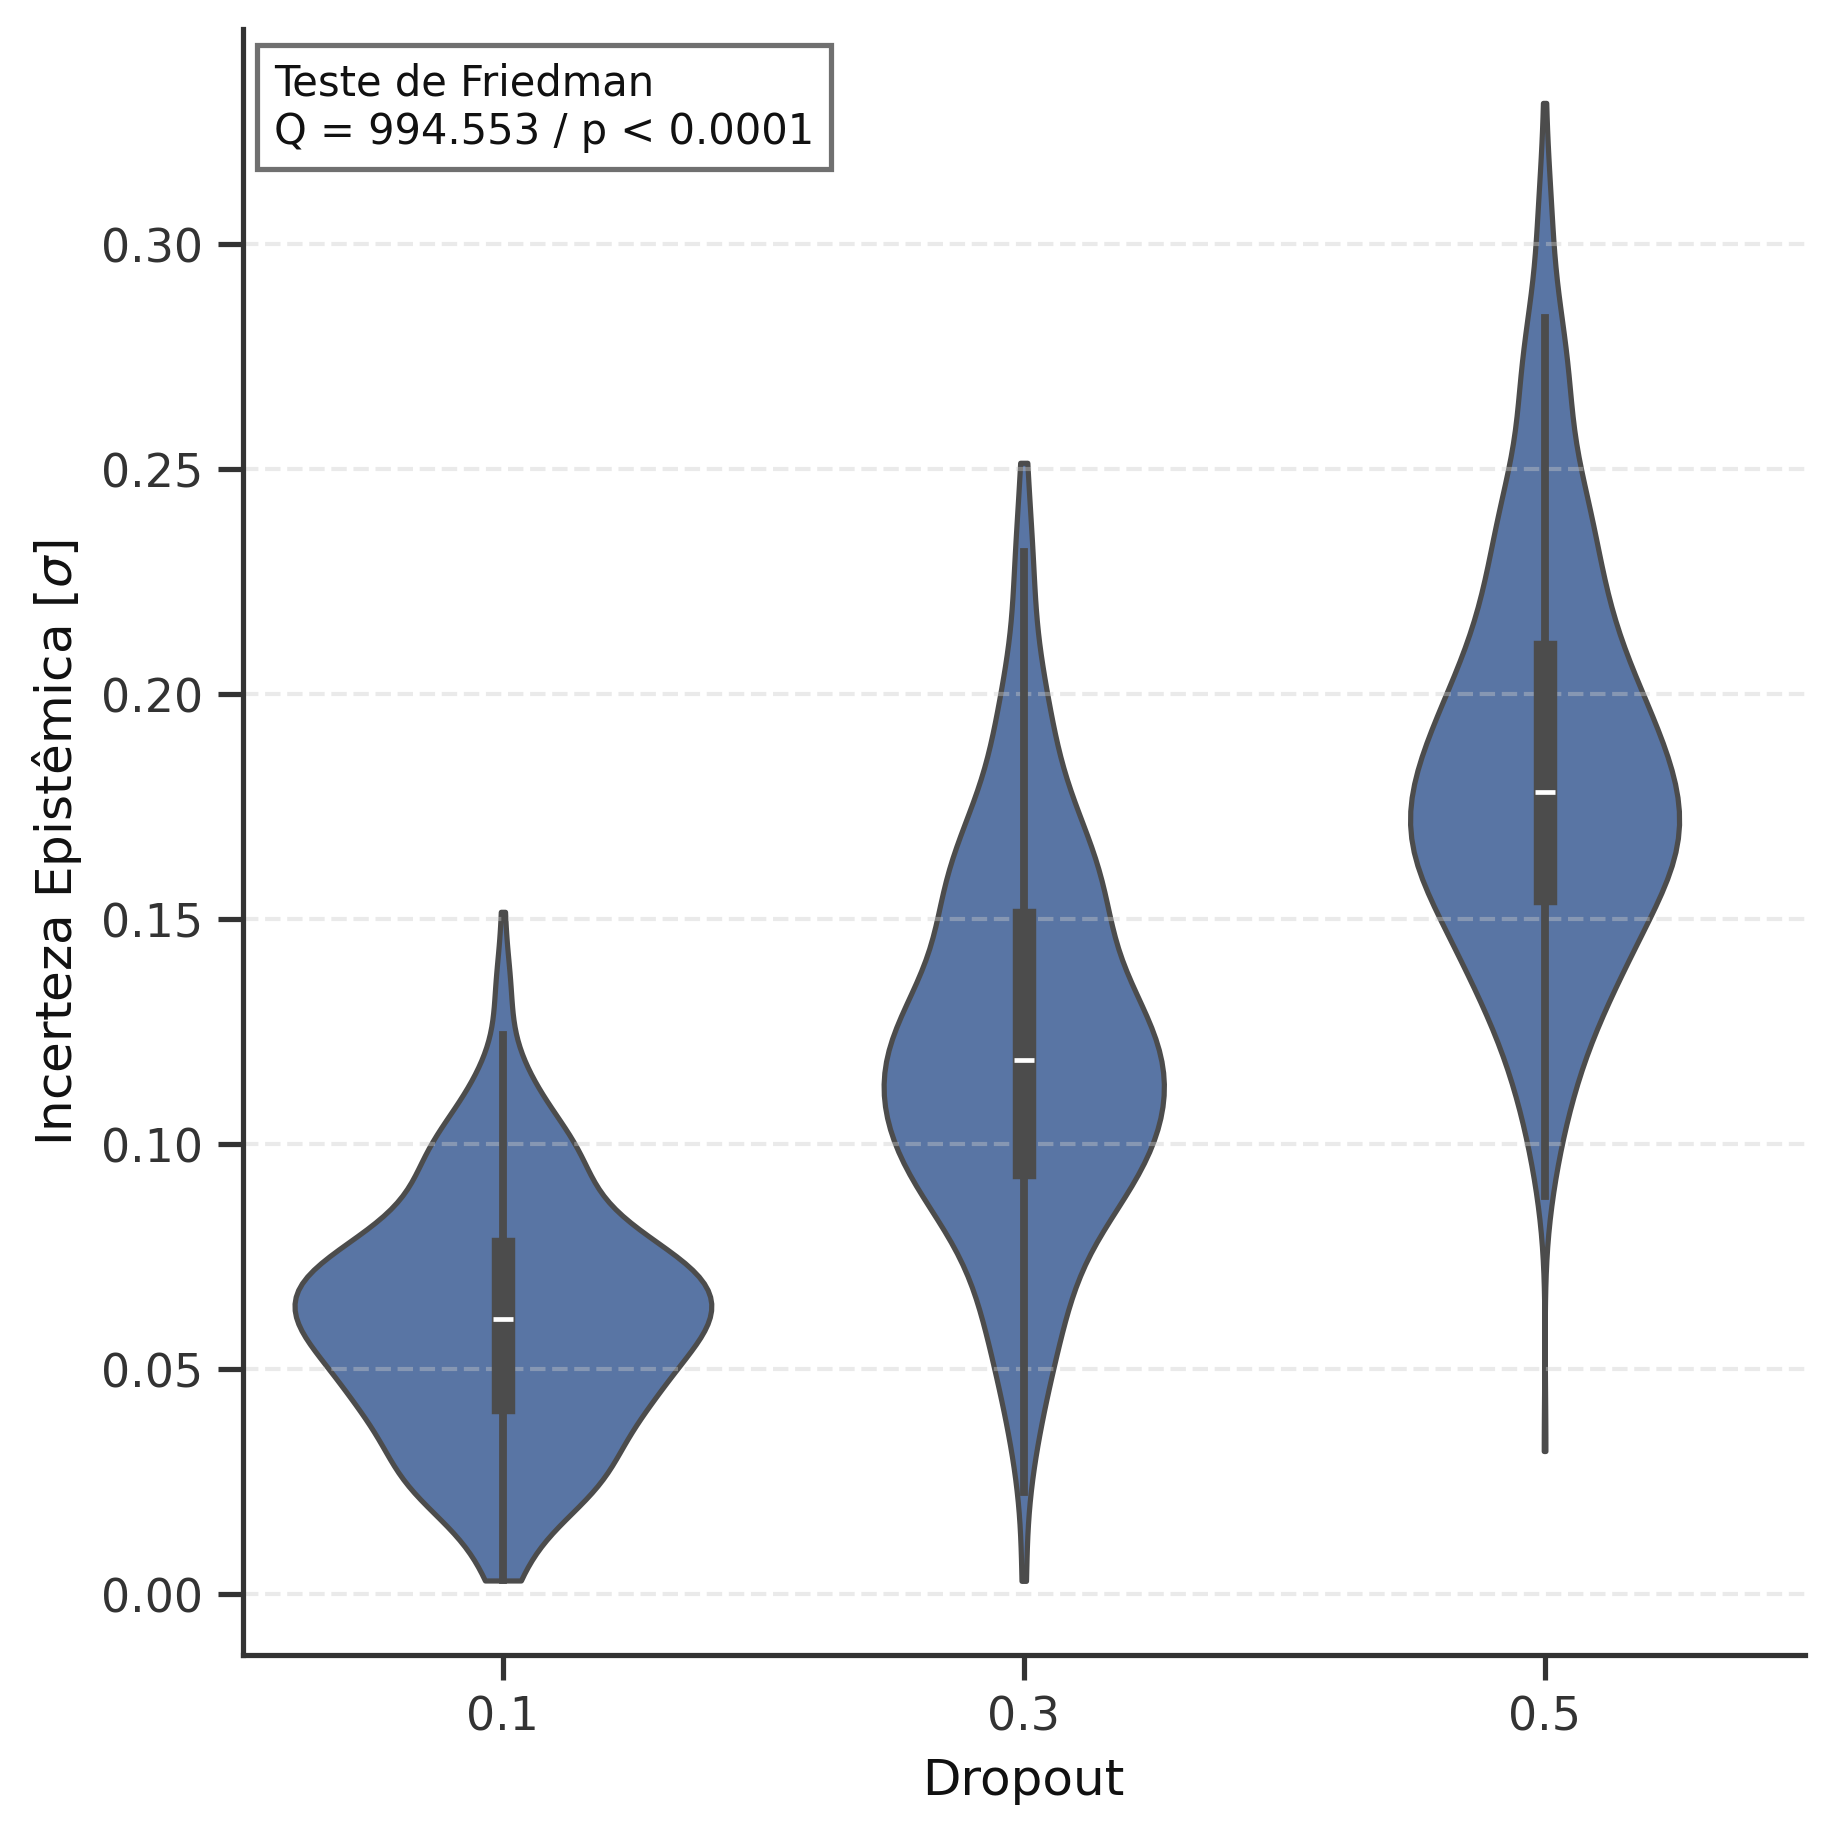

In [29]:
plt.style.use(r"utils\painxai.mplstyle")
sns.set_theme(style=None)   # critical line

fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

sns.violinplot(
    data=dataframe_MCDP,
    x="Dropout",
    y=mode,
    ax=ax,
    inner="box",   # shows median + IQR; change to "box" or None if you prefer
    cut=0               # avoids extending beyond data range
)

# Labels (match x/y!)
ax.set_xlabel("Dropout")
ax.set_ylabel(r"Incerteza Epistêmica [$\sigma$]")

# Annotation in axes coords (0..1), independent of data scale
ax.text(
    0.02, 0.98, ks_text,
    transform=ax.transAxes,
    fontsize=10,
    va="top", ha="left",
    bbox=dict(
    facecolor=plt.rcParams["figure.facecolor"],
    edgecolor=plt.rcParams["axes.edgecolor"],
    linewidth=plt.rcParams["axes.linewidth"],
    alpha=0.70
)
)

fig.savefig(f"incerteza_MCDP.pdf", bbox_inches="tight")


In [ ]:
fig = plt.figure()

gs = fig.add_gridspec(2, 1,  height_ratios=(3, 1), left=0.1, right=0.9, bottom=0.1, top=0.9, hspace=0.02)

ax_kde = fig.add_subplot(gs[0])
ax_boxplot = fig.add_subplot(gs[1], sharex=ax_kde)

sns.kdeplot(data=dataframe_MCDP, x=mode, hue='Dropout', fill=True, ax=ax_kde)
sns.boxplot(data=dataframe_MCDP, x=mode, hue='Dropout', width=0.5, ax=ax_boxplot, linewidth=0.9)

#ax_kde.set_title('Uncertainty [$\sigma$] distribution over predictions')
ax_kde.set_ylabel('Densidade')
#ax_kde.set_xlim([-0.09, 0.4])
ax_kde.tick_params(axis='x', labelbottom=False)

ax_kde.text(0.2, 0.83, ks_text, transform=ax_kde.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='center')

ax_boxplot.set_xlabel('Incerteza Epistêmica [$\sigma$]')
ax_boxplot.get_legend().remove()
plt.savefig(f'{model}_MCDP.pdf',  
                    bbox_inches='tight')

In [ ]:

# ────────────────────────────────────────────────────────────────────────────────
# 2. Run on the three datasets
# ────────────────────────────────────────────────────────────────────────────────
dataframes = {
    'stds_0.1' : stds_1,
    'stds_0.3' : stds_3,
    'stds_0.5': stds_5
}

fold_results   = {}   # store per-fold tables
summary_rows   = []   # store mean ± SD lines

for name, df in dataframes.items():
    corr_df = correlation_by_fold(df)   # step 1
    fold_results[name] = corr_df        # keep the detailed table

    summary_rows.append({
        'setting'        : name,
        'spearman_mean'  : corr_df['spearman_r'].mean(),
        'spearman_std'   : corr_df['spearman_r'].std(ddof=1),
        'pearson_mean'   : corr_df['pearson_r'].mean(),
        'pearson_std'    : corr_df['pearson_r'].std(ddof=1)
    })

summary = pd.DataFrame(summary_rows).set_index('setting')

# Header row
header = ["setting",
          "Spearman (ρ ± SD)",
          "Pearson (r ± SD)"]
print("\t".join(header))        # tab-delimited so Sheets splits columns

for name, row in summary.iterrows():
    s = f"{fmt(row['spearman_mean'])} ± {fmt(row['spearman_std'])}"
    p = f"{fmt(row['pearson_mean'])} ± {fmt(row['pearson_std'])}"
    print("\t".join([name, s, p]))

## ENSEMBLE

In [30]:
path_experiments = f'experiments\\{model}_ENSEMBLE'


filename = f'ensemble_3_results.pkl'
with open(os.path.join(path_experiments, filename), 'rb') as f:
    results_30 = pd.DataFrame(pickle.load(f))

results_30['Ensembles'] = ['3'] * len(results_30)
results_30['stds'] = np.array(results_30['probs_uq'].tolist()).std(axis=1)
results_30['predictive_entropy'] = binary_entropy(np.mean(results_30['probs_uq'].tolist(), axis=1))
results_30['corrects'] = results_30['labels'] == results_30['preds']

filename = f'ensemble_5_results.pkl'
with open(os.path.join(path_experiments, filename), 'rb') as f:
    results_50 = pd.DataFrame(pickle.load(f))

results_50['Ensembles'] = ['5'] * len(results_50)
results_50['stds'] = np.array(results_50['probs_uq'].tolist()).std(axis=1)
results_50['predictive_entropy'] = binary_entropy(np.mean(results_50['probs_uq'].tolist(), axis=1))
results_50['corrects'] = results_50['labels'] == results_50['preds']

filename = f'ensemble_10_results.pkl'
with open(os.path.join(path_experiments, filename), 'rb') as f:
    results_100 = pd.DataFrame(pickle.load(f))

results_100['Ensembles'] = ['10'] * len(results_100)
results_100['stds'] = np.array(results_100['probs_uq'].tolist()).std(axis=1)
results_100['predictive_entropy'] = binary_entropy(np.mean(results_100['probs_uq'].tolist(), axis=1))
results_100['corrects'] = results_100['labels'] == results_100['preds']

dataframe_ensemble = pd.concat([results_30, results_50, results_100], ignore_index=True)

In [31]:
ensemble_3 = dataframe_ensemble[dataframe_ensemble["Ensembles"]=="3"]
ensemble_5 = dataframe_ensemble[dataframe_ensemble["Ensembles"]=="5"]
ensemble_10 = dataframe_ensemble[dataframe_ensemble["Ensembles"]=="10"]

# Assuming you have three lists/arrays of stds
stat, p = kruskal(ensemble_3['stds'], ensemble_5['stds'], ensemble_10['stds'])
print(f"Kruskal-Wallis H = {stat:.4f}, p = {p:.4}")


Kruskal-Wallis H = 86.1494, p = 1.963e-19


In [32]:
ks_statistic, p_value = friedmanchisquare(ensemble_3['stds'], ensemble_5['stds'], ensemble_10['stds'])

if p_value < 0.0001:
    p_text = f"p < 0.0001"
else:
    p_text = f"p = {p_value:.4f}"
    
ks_text = f"Teste de Friedman\nQ = {ks_statistic:.3f} / {p_text}"

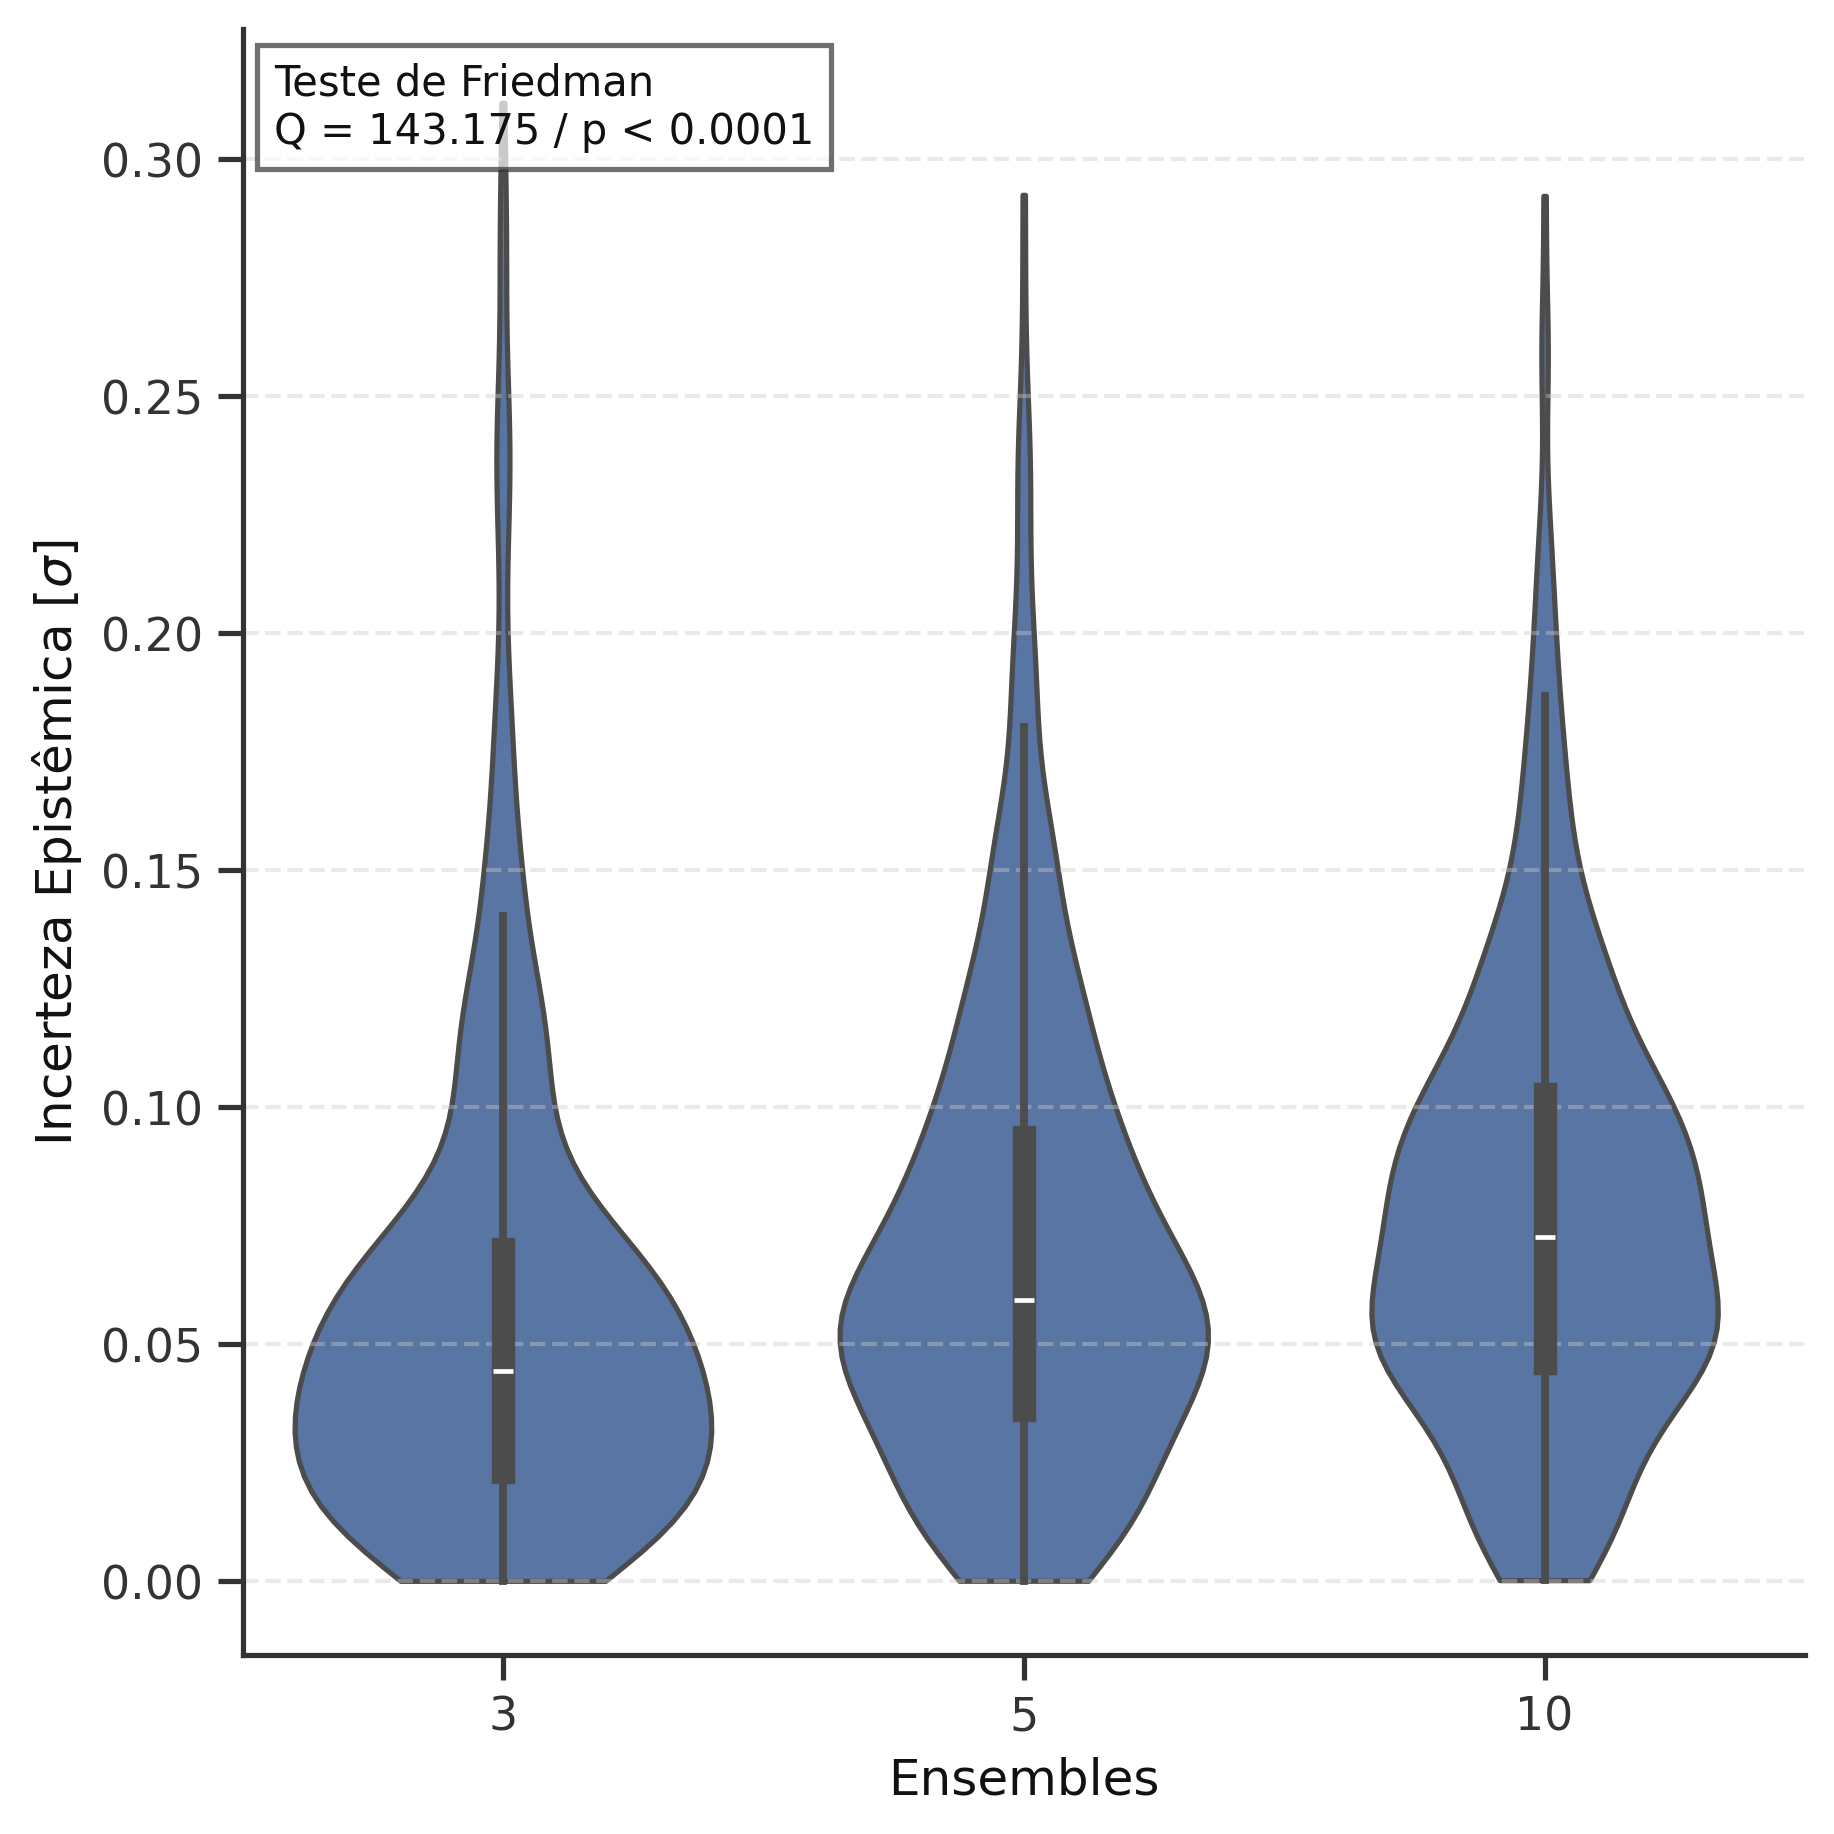

In [33]:
plt.style.use(r"utils\painxai.mplstyle")
sns.set_theme(style=None)   # critical line

fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

sns.violinplot(
    data=dataframe_ensemble,
    x="Ensembles",
    y=mode,
    ax=ax,
    inner="box",   # shows median + IQR; change to "box" or None if you prefer
    cut=0               # avoids extending beyond data range
)

# Labels (match x/y!)
ax.set_xlabel("Ensembles")
ax.set_ylabel(r"Incerteza Epistêmica [$\sigma$]")

# Annotation in axes coords (0..1), independent of data scale
ax.text(
    0.02, 0.98, ks_text,
    transform=ax.transAxes,
    fontsize=10,
    va="top", ha="left",
    bbox=dict(
    facecolor=plt.rcParams["figure.facecolor"],
    edgecolor=plt.rcParams["axes.edgecolor"],
    linewidth=plt.rcParams["axes.linewidth"],
    alpha=0.70
)
)

fig.savefig(f"incerteza_ensembles.pdf", bbox_inches="tight")


In [ ]:
fig = plt.figure()

gs = fig.add_gridspec(2, 1,  height_ratios=(3, 1), left=0.1, right=0.9, bottom=0.1, top=0.9, hspace=0.02)

ax_kde = fig.add_subplot(gs[0])
ax_boxplot = fig.add_subplot(gs[1], sharex=ax_kde)

sns.kdeplot(data=dataframe_ensemble, x=mode, hue='Ensembles', fill=True, ax=ax_kde)
sns.boxplot(data=dataframe_ensemble, x=mode, hue='Ensembles', width=0.5, ax=ax_boxplot, linewidth=0.9)

#ax_kde.set_title('Uncertainty [$\sigma$] distribution over predictions')
ax_kde.set_ylabel('Densidade')
#ax_kde.set_xlim([-0.09, 0.4])
ax_kde.tick_params(axis='x', labelbottom=False)

ax_kde.text(0.6, 0.83, ks_text, transform=ax_kde.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='center')


ax_boxplot.set_xlabel('Incerteza Epistêmica [$\sigma$]')
ax_boxplot.get_legend().remove()
plt.savefig(f'{model}_ensembles.pdf',  
                    bbox_inches='tight')

In [ ]:

# ────────────────────────────────────────────────────────────────────────────────
# 2. Run on the three datasets
# ────────────────────────────────────────────────────────────────────────────────
dataframes = {
    'ensemble_3' : ensemble_3,
    'ensemble_5' : ensemble_5,
    'ensemble_10': ensemble_10
}

fold_results   = {}   # store per-fold tables
summary_rows   = []   # store mean ± SD lines

for name, df in dataframes.items():
    corr_df = correlation_by_fold(df)   # step 1
    fold_results[name] = corr_df        # keep the detailed table

    summary_rows.append({
        'setting'        : name,
        'spearman_mean'  : corr_df['spearman_r'].mean(),
        'spearman_std'   : corr_df['spearman_r'].std(ddof=1),
        'pearson_mean'   : corr_df['pearson_r'].mean(),
        'pearson_std'    : corr_df['pearson_r'].std(ddof=1)
    })

summary = pd.DataFrame(summary_rows).set_index('setting')

# Header row
header = ["setting",
          "Spearman (ρ ± SD)",
          "Pearson (r ± SD)"]
print("\t".join(header))        # tab-delimited so Sheets splits columns

for name, row in summary.iterrows():
    s = f"{fmt(row['spearman_mean'])} ± {fmt(row['spearman_std'])}"
    p = f"{fmt(row['pearson_mean'])} ± {fmt(row['pearson_std'])}"
    print("\t".join([name, s, p]))

# MCDP in lower dimension

# MCDP in lower dimension

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import torch
from torchvision import transforms

from models import *
from uncertainty.MCDropout import MCDropout

import matplotlib.pyplot as plt
import os
import cv2
import numpy as np
import pickle

In [ ]:
model = VGGNB()

In [ ]:
model.eval()
model.load_state_dict(torch.load('experiments\\UNIFESP+iCOPE\\VGGNB\\20241012_1628_VGGNB\\Model\\best_model.pt'))
model = model.to('cuda')


In [ ]:
model_mcdp = MCDropout(model, p=0.5)


In [ ]:
img_size = 224
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224,224), antialias=False),
    transforms.Normalize(
        mean=[0.36703529, 0.41083294, 0.50661294], std=[1, 1, 1])
])


In [ ]:
image = cv2.imread('C:\\Users\\leonardo\\Desktop\\Mestrado\\Datasets\\Folds\\5\\Test\\ID1105_UNIFESP_S99_nopain.jpg')


In [ ]:
embeddings_mcdp = []

def hook(model, input, output):
    output = output.detach().cpu().numpy()
    for x in output:
        embeddings_mcdp.append(x.flatten())

In [ ]:
f_hook = model_mcdp.model.VGGFace.classifier[3].register_forward_hook(hook)     

In [ ]:
with torch.no_grad():
    img = image / 255
    img = np.float32(img)
    img = transform(image).to('cuda')   

    img_batch = img.unsqueeze(0)

    probs_mcdp = model_mcdp.predict(img_batch, reps=100)

f_hook.remove()

In [ ]:
np.array(embeddings_mcdp).shape

In [ ]:
folder = 'VGGFace'
model = 'VGGFace'
path_experiments = f'experiments\\{folder}\\{model}'

filename = 'results.pkl'

with open(os.path.join(path_experiments, filename), 'rb') as f:
    results = pickle.load(f)

probs = []
embeddings = []

for i, fold in enumerate(results.keys()):
  
    probs.extend(results[fold]['probs'])
    embeddings.extend(results[fold]['embeddings'])
   
scaler = MinMaxScaler()

embeddings_norm = scaler.fit_transform(embeddings)
embeddings_norm_mcdp = scaler.transform(embeddings_mcdp)

pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings_norm)
embeddings_pca_mcdp = pca.transform(embeddings_norm_mcdp)

plt.scatter(embeddings_pca[:,0], embeddings_pca[:,1], c=probs)
plt.scatter(embeddings_pca_mcdp[:,0], embeddings_pca_mcdp[:,1], color='r')
plt.colorbar()

In [ ]:
probs_mcdp = np.array(probs_mcdp.cpu())[0]

In [ ]:
plt.hist(probs_mcdp, bins=10, range=[0,1])
plt.xlim([0,1])

In [ ]:
probs_mcdp.mean()

In [ ]:
probs_mcdp.std()

In [ ]:
from sklearn.metrics import log_loss

log_loss(np.zeros(shape=probs_mcdp.shape), probs_mcdp, labels=[0,1])